## Bachelor Thesis 2026 Högskolan Kristianstad 

### *Patrik Engblom and Erik Karlsson* 

**Creating a SOM-model for ESP32-S3**

Pipeline for creating a Self Organizing Map for physiological biosignals (GSR and PPG) for classification of stress levels.

1. Loading CSV fil and convert into dataframe

2. Create SOM model using GeneralClassSOM (developed from MiniSom)

3. Train model. 

4. Use analysis tools to evaluate SOM-map

5. Create clusters using K-means clustering. 

6. Analysis of cluster characterstics. 

7. Label clustes.

8. Save files for further use (h.files and pkl.files)

### 1. IMPORTS USED DURING THE PROJECT
- `numpy` (`np`) — Numerical computing library used for arrays, matrix operations, and mathematical calculations.

- `pandas` (`pd`) — Data analysis library used for handling and processing tabular data with DataFrames.

- `Path` from `pathlib` — Used for platform-independent file and folder path handling.

- `matplotlib.pyplot` (`plt`) — Visualization library used for creating plots and figures.

- `ListedColormap` — Utility from Matplotlib used to create custom color maps for visualizations.

- `seaborn` (`sns`) — Statistical visualization library built on Matplotlib for simplified and enhanced plotting.

- `PCA` from `sklearn.decomposition` — Principal Component Analysis used for dimensionality reduction and visualization of high-dimensional data.

- `StandardScaler` — Standardizes features by removing the mean and scaling to unit variance.

- `f_classif` — ANOVA F-score function used to measure feature importance between clusters/classes.

- `combinations` from `itertools` — Generates all possible pairwise combinations between clusters.

- `GeneralCLASSOM` — Custom SOM-based clustering model used for training, clustering, and analysis of physiological data.

In [ ]:
# Cell 1

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import seaborn as sns 

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import f_classif
from itertools import combinations
from som_model import GeneralCLASSOM

### 2. CSV to dataframe 

Load csv with extracted features from train_features_fulltest_200.ipynb. 

Pandas lib to make dataframe.

In [5]:
#  Cell 2

df = pd.read_csv("../data/processed/eda_ppg_features_for_som/features_all_SOM.csv")

#check the dataframe 
df.describe()

,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,time_sec,SC_PH,SC_RR,EDA_slope
count,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000,5327.000000,5327.0,5327.000000,5327.000000,5327.000000,5327.000000
mean,79.844691,47.494655,47.329659,62.605699,765.662418,62.195541,609.012577,936.459546,79.400788,0.944308,1.0,1107.178524,12.362841,0.089922,0.000050
std,11.047150,16.161628,16.008275,24.485428,104.429844,24.310644,108.423574,130.418012,11.075572,0.084675,0.0,647.455445,88.808030,0.061380,0.000206
min,54.774103,8.794114,8.779079,15.454561,449.375000,15.382846,405.000000,510.000000,48.000000,0.450704,1.0,0.000000,0.002407,0.000000,-0.000287
25%,72.331188,35.039077,35.016258,44.896700,693.063686,44.616821,535.000000,855.000000,72.000000,0.921348,1.0,547.500000,0.476210,0.050000,-0.000164
50%,78.437862,47.299217,47.262308,58.568094,764.936709,58.198322,605.000000,945.000000,78.000000,0.985507,1.0,1095.000000,1.779381,0.083333,0.000094
75%,86.572131,59.969544,59.628496,77.113763,829.517694,76.623736,690.000000,1025.000000,85.000000,1.000000,1.0,1665.000000,5.498094,0.133333,0.000259
max,133.518776,93.654952,93.651949,180.855996,1095.408163,179.342530,990.000000,1195.000000,128.000000,1.000000,1.0,2265.000000,2363.962167,0.350000,0.000289


### 3. Feature tuning before SOM Model. (SC_PH AND PPG RR)

SC_PH Logaritm function

SC_PH is highly skewed, so we will log-transform it and then clip the outliers

RR_Quality (PPG) - Filtering was applied to improve data quality and reduce the influence of incorrect peak detections and noise in the PPG signal.



In [6]:
# Cell 3

# SC_PH log transformation and outlier clipping
df["SC_PH"] = np.log1p(df["SC_PH"])
low, high = df["SC_PH"].quantile([0.01, 0.99])
df["SC_PH"] = df["SC_PH"].clip(low, high)

# PPG RR quality filtering
df = df[df["RR_quality"] > 0.7]

# check the dataframe again after filtering
df.describe()

,HR,HRV_RMSSD,RR_diff_std,HRV_SDNN,RR_mean,RR_std,RR_min,RR_max,RR_count,RR_quality,RR_valid,time_sec,SC_PH,SC_RR,EDA_slope
count,5193.000000,5193.000000,5193.000000,5193.000000,5193.000000,5193.000000,5193.000000,5193.000000,5193.000000,5193.000000,5193.0,5193.000000,5193.000000,5193.000000,5193.000000
mean,79.837277,46.875096,46.733235,60.920880,765.978600,60.522105,612.998267,932.016176,79.485269,0.952293,1.0,1099.150780,1.297458,0.090163,0.000049
std,11.141116,15.837816,15.710243,22.261026,105.336243,22.100742,106.627969,128.650951,11.171836,0.068747,0.0,644.915989,1.115019,0.061268,0.000206
min,54.774103,8.794114,8.779079,15.454561,449.375000,15.382846,405.000000,510.000000,48.000000,0.701299,1.0,0.000000,0.013305,0.000000,-0.000287
25%,72.252885,34.846603,34.788140,44.521932,692.126437,44.254886,535.000000,850.000000,72.000000,0.930233,1.0,540.000000,0.403372,0.050000,-0.000165
50%,78.437862,46.672619,46.573529,57.826398,764.936709,57.483155,610.000000,940.000000,78.000000,0.986111,1.0,1095.000000,1.051339,0.083333,0.000089
75%,86.689363,59.008664,58.847109,75.460276,830.416667,74.963038,695.000000,1015.000000,86.000000,1.000000,1.0,1650.000000,1.886950,0.133333,0.000258
max,133.518776,93.205623,92.703575,163.833765,1095.408163,162.568620,990.000000,1195.000000,128.000000,1.000000,1.0,2265.000000,5.297744,0.350000,0.000289


### 4. Extract correct features

Four inputs from df - HR, HRV_RMSSD, SC_PH, SC_RRC

Check so correct df 

In [7]:
# Cell 4

#create a new dataframe with only the features we want to use for the SOM
df_som = df[['HR', 'HRV_RMSSD','SC_PH', 'SC_RR']].copy()

#check the new dataframe
print("Shape:", df_som.shape)
print("\nColumns:")
print(df_som.columns)

print("\nDescribe:")
print(df_som.describe())

Shape: (5193, 4)

Columns:
Index(['HR', 'HRV_RMSSD', 'SC_PH', 'SC_RR'], dtype='str')

Describe:
                HR    HRV_RMSSD        SC_PH        SC_RR
count  5193.000000  5193.000000  5193.000000  5193.000000
mean     79.837277    46.875096     1.297458     0.090163
std      11.141116    15.837816     1.115019     0.061268
min      54.774103     8.794114     0.013305     0.000000
25%      72.252885    34.846603     0.403372     0.050000
50%      78.437862    46.672619     1.051339     0.083333
75%      86.689363    59.008664     1.886950     0.133333
max     133.518776    93.205623     5.297744     0.350000


## 5. Create SOM-model

Model created from GeneralCLASSOM 

*OUTPUT:* SOM-model paramters and functions used. 

In [2]:
# Cell 5
# 22x22 grid, 4 input features, sigma=8, learning rate=0.1, random seed=42

som_clas_200 = GeneralCLASSOM(
    x=22,
    y=22,
    input_len=4,

    sigma=8,
    learning_rate=0.1,

    random_seed=42
)
# print the SOM summary (not changed above default values)
som_clas_200.get_summary()

{'x': 22,
 'y': 22,
 'input_len': 4,
 'sigma': 8,
 'learning_rate': 0.1,
 'decay_function': 'asymptotic_decay',
 'neighborhood_function': 'gaussian',
 'topology': 'rectangular',
 'activation_distance': 'euclidean',
 'sigma_decay_function': 'asymptotic_decay',
 'random_seed': 42}

### 6. Check use of BMU before traning the model. 

Controlling distribution before traing to see how the data is formed. 

PCA init used for the weights 

Higer unique BMU indicate well spread data across the grid.

In [8]:
# Cell 6

# using debug bmu distrution method. 
som_clas_200.inspect_bmu_distribution(df_som)

Total samples: 5193
Unique BMUs: 132
Map size: 484


array([[14,  3],
       [ 9,  9],
       [ 7, 10],
       ...,
       [11, 12],
       [11, 13],
       [11, 13]], shape=(5193, 2))

## 7. TRAIN MODEL

train function using scaler by deafault (MinMaxScaler)

*60000 iterations:*

5193 feature vectors

*Training mode: Batch*,

One feature vector is processed per iteration to find the Best Matching Unit and update the SOM grid.

Using PCA init of the weights. 

OUTPUT: 

Quantization Error and Topographic Error, for analysis model. 



In [7]:
# Cell 7 

som_clas_200.train(

   df_som,

    iterations=60000,
    mode="batch",

    use_pca=True,
    verbose=True
)

 [ 60000 / 60000 ] 100% - 0:00:00 left 
 quantization error: 0.14660583482348838
Quantization Error: 0.1466
Topographic Error: 0.0322
Training completed (60000 iterations)


### 8. Check unique BMU AFTER training 

Checking so the map is proper fit to the amount of datapoints (vectors)

In [8]:
# cell 8

scaled = som_clas_200.scaler.transform(df_som)

winners = np.array([som_clas_200.som.winner(x) for x in scaled])

unique_bmus = set(map(tuple, winners))

print("Total samples:", len(df_som))
print("Unique BMUs:", len(unique_bmus))
print("Map size:", som_clas_200.x * som_clas_200.y)
print("Coverage:", len(unique_bmus) / (som_clas_200.x * som_clas_200.y))

Total samples: 5193
Unique BMUs: 462
Map size: 484
Coverage: 0.9545454545454546


### 9. SOM NEURON ANALYSIS

1. Feature-wise variation
Each feature should show variation across the map.

2. Weight planes (component maps)
Each feature is visualized across the SOM grid.

3. Neuron variance
Measures how much each neuron varies across features.

4. Dead neurons
Neurons with very low variance

5. Weight distribution
Histogram of all weights

=== BASIC INFO ===
Shape: (22, 22, 4)
Global min: 0.010163062795735393
Global max: 0.7990198003846494
Global variance: 0.02289031907889276

=== FEATURE-WISE RANGE ===
Feature 0: min=0.098, max=0.528, var=0.0120
Feature 1: min=0.226, max=0.668, var=0.0135
Feature 2: min=0.035, max=0.799, var=0.0287
Feature 3: min=0.010, max=0.547, var=0.0163

=== VISUALIZING WEIGHT PLANES ===


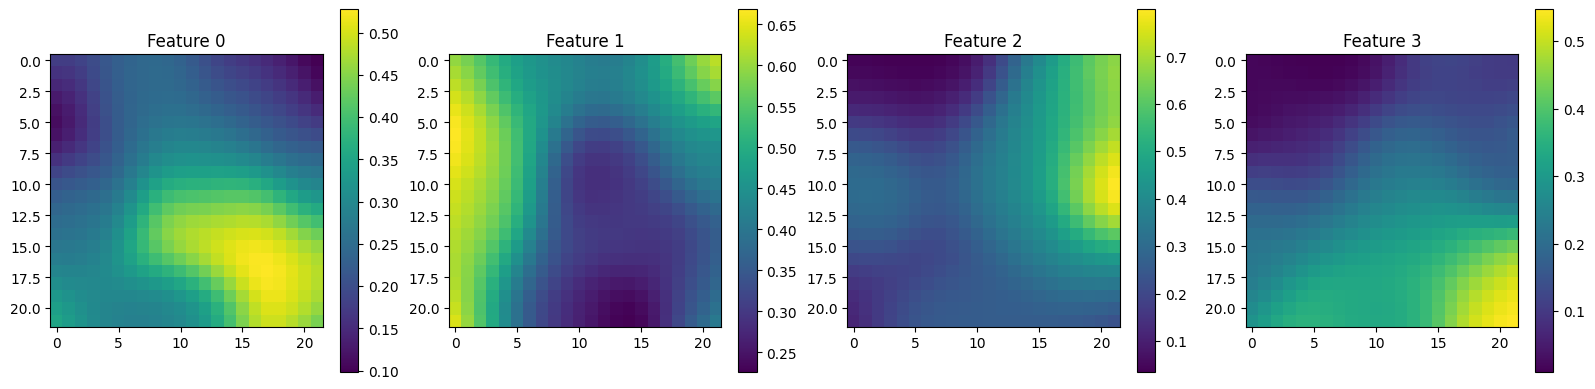


=== NEURON VARIATION ===
Neuron variance stats:
min: 0.0008232933268915901
max: 0.07429325180728641
mean: 0.019213137604962356


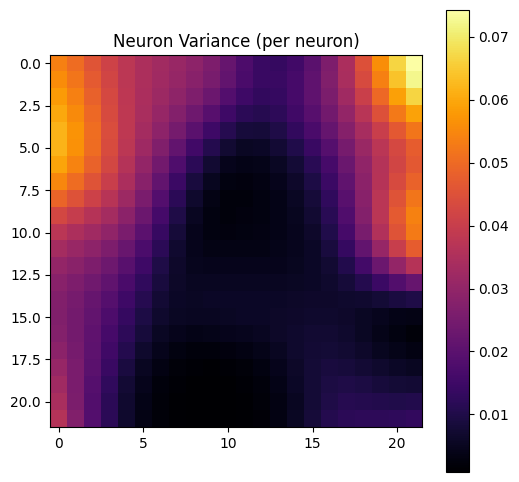


=== LOW VARIANCE NEURONS ===
Low-variance neurons (<5th percentile): 25


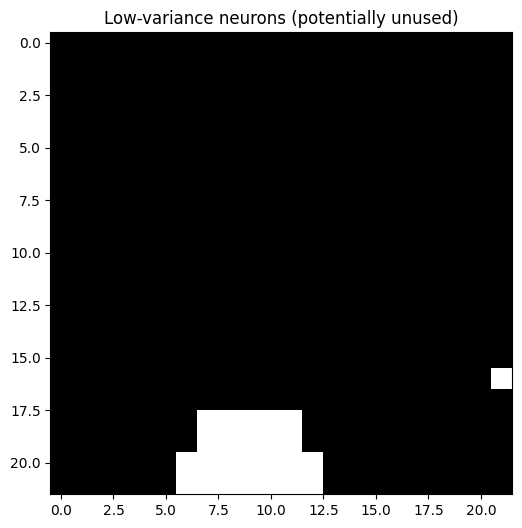


=== WEIGHT DISTRIBUTION ===


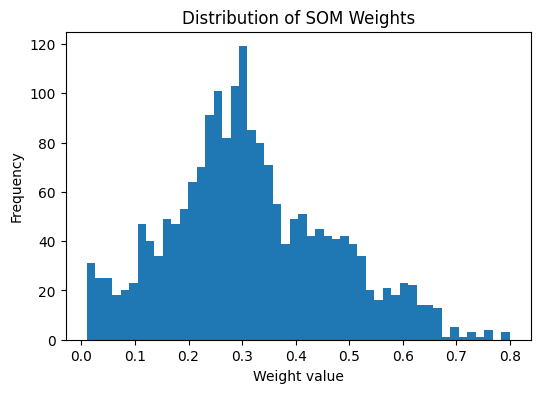

In [9]:
# Cell 9

# weights shape: (x, y, features)
weights = som_clas_200.som.get_weights()  
print("=== BASIC INFO ===")
print("Shape:", weights.shape)
print("Global min:", weights.min())
print("Global max:", weights.max())
print("Global variance:", np.var(weights))


# 1. FEATURE-WISE ANALYS 
print("\n=== FEATURE-WISE RANGE ===")

n_features = weights.shape[2]

for i in range(n_features):
    w = weights[:, :, i]
    print(f"Feature {i}: min={w.min():.3f}, max={w.max():.3f}, var={np.var(w):.4f}")


# 2.WEIGHT PLANES
print("\n=== VISUALIZING WEIGHT PLANES ===")

fig, axes = plt.subplots(1, n_features, figsize=(4*n_features, 4))

for i in range(n_features):
    ax = axes[i] if n_features > 1 else axes
    im = ax.imshow(weights[:, :, i], cmap="viridis")
    ax.set_title(f"Feature {i}")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


# 3. NEURON VARIATION 
print("\n=== NEURON VARIATION ===")

neuron_variance = np.var(weights, axis=2)

print("Neuron variance stats:")
print("min:", neuron_variance.min())
print("max:", neuron_variance.max())
print("mean:", neuron_variance.mean())

plt.figure(figsize=(6,6))
plt.imshow(neuron_variance, cmap="inferno")
plt.colorbar()
plt.title("Neuron Variance (per neuron)")
plt.show()


# 4. DEAD / LOW-ACTIVITY NEURONS
print("\n=== LOW VARIANCE NEURONS ===")

threshold = np.percentile(neuron_variance, 5)

dead_mask = neuron_variance < threshold
num_dead = np.sum(dead_mask)

print(f"Low-variance neurons (<5th percentile): {num_dead}")

plt.figure(figsize=(6,6))
plt.imshow(dead_mask, cmap="gray")
plt.title("Low-variance neurons (potentially unused)")
plt.show()


# 5. WEIGHT DISTRIBUTION
print("\n=== WEIGHT DISTRIBUTION ===")

plt.figure(figsize=(6,4))
plt.hist(weights.flatten(), bins=50)
plt.title("Distribution of SOM Weights")
plt.xlabel("Weight value")
plt.ylabel("Frequency")
plt.show()

### 10. Clustering 

Creates SOM neuron clusters using density-aware KMeans clustering. The trained SOM weights are used as input, while the original feature data (`df_som`) is used to calculate neuron activation density. Neurons that are activated more frequently by the input data receive higher importance during clustering. 

The SOM map is divided into 3 clusters. (n_klusters)

In [ ]:
# cell 10

cluster_map = som_clas_200.create_clusters(
    data=df_som,
    n_clusters=3,
    method="density"
) 

### 11. SOM Analysis Panel

1. U-Matrix (Unified Distance Matrix)
The U-Matrix visualizes the average distance between neighboring neurons.

- Light areas → **similar neurons (clusters)**
- Dark areas → **large distances (cluster boundaries)**

2. Hit Map **(Activation Map)**
The hit map shows how many data samples are mapped to each neuron.

3. Cluster Map
Displays clustering results applied to SOM neurons (here using density-aware KMeans).

4. U-Matrix + Cluster Overlay
Combines structural information (U-Matrix) with clustering.

5. Feature Maps (Component Planes)

Each feature is visualized across the SOM grid using neuron weights.

Each feature map shows how that variable varies across the SOM:

- Smooth gradients → structured relationship  
- Sharp transitions → strong separation between regions  
- Uniform areas → low influence of that feature  

Feature maps help identify:

- Which variables drive clustering  
- Relationships between physiological signals  
- Correlations (e.g., HR vs HRV)  
- Regions of high/low activation  

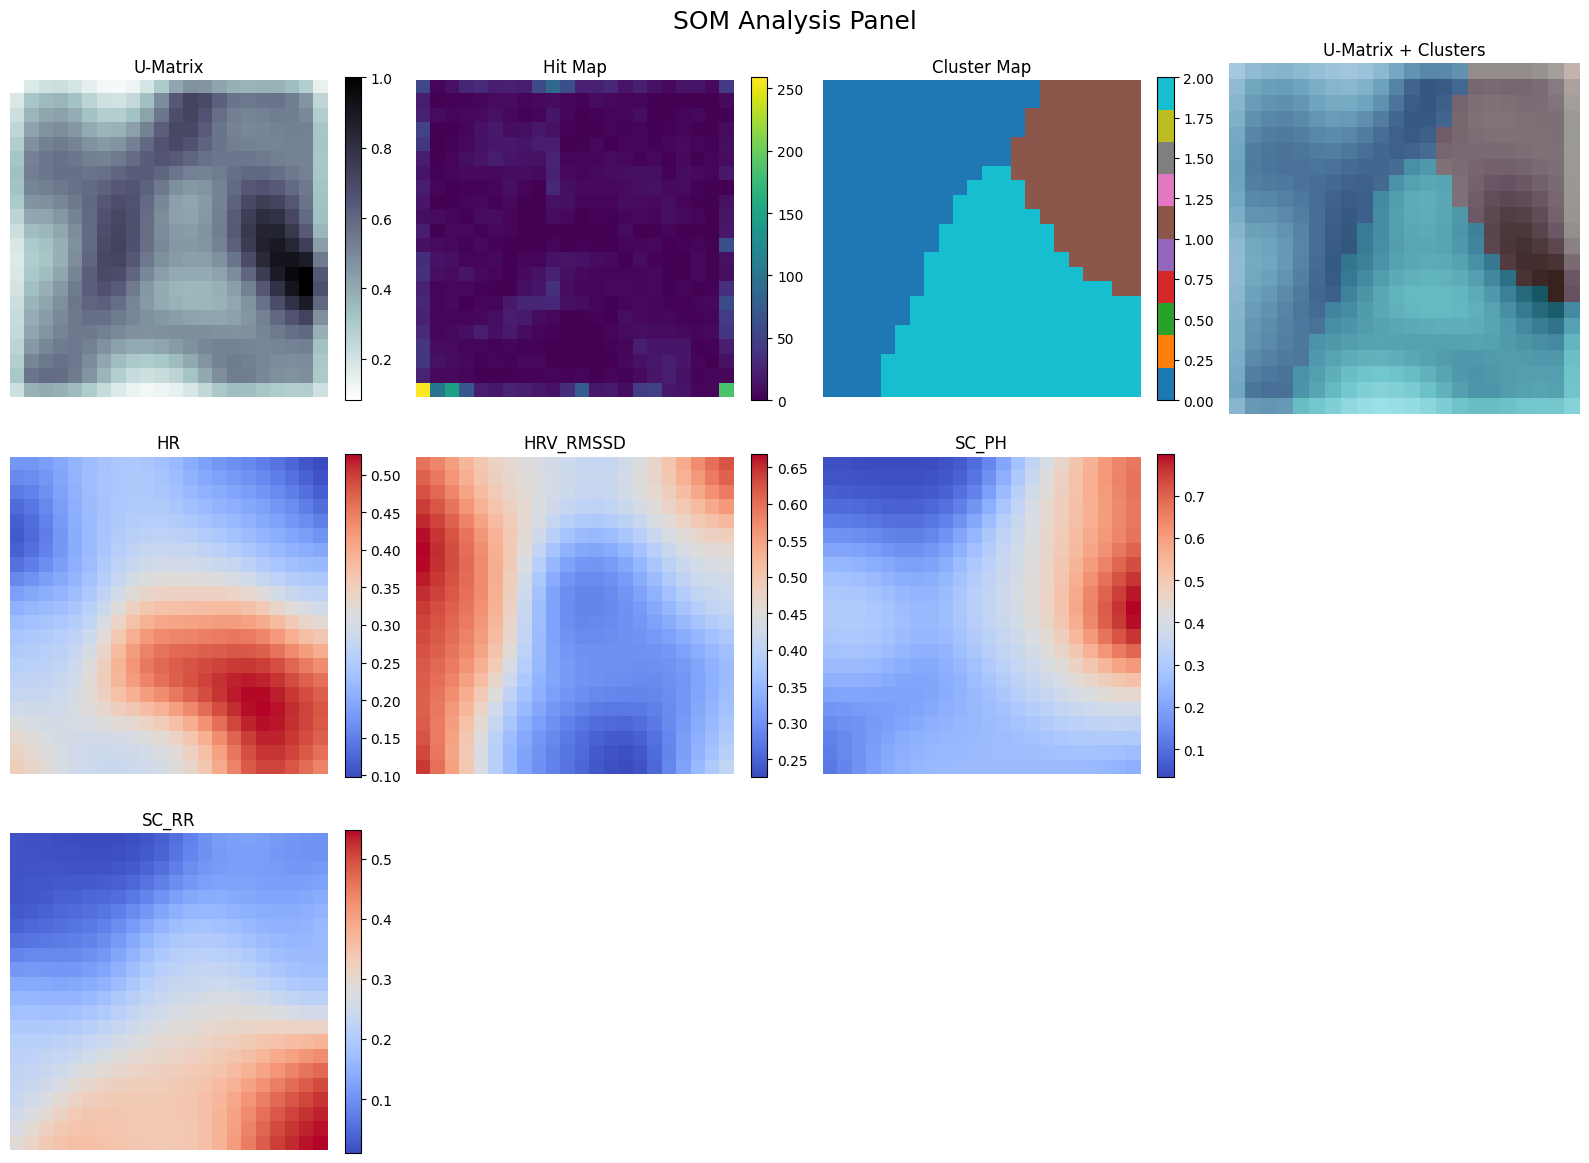

In [13]:
# Cell 11

# ---- Prepare data ----
scaled_data = som_clas_200.scaler.transform(df_som)

u_matrix = som_clas_200.get_u_matrix()

hits = som_clas_200.som.activation_response(scaled_data)

cluster_map = som_clas_200.kmeans.labels_.reshape(som_clas_200.x, som_clas_200.y)

weights = som_clas_200.som.get_weights()

feature_names = [
    "HR",
    "HRV_RMSSD", 
    "SC_PH", 
    "SC_RR"
]

# ---- Figure layout ----
fig = plt.figure(figsize=(16,12))

grid = fig.add_gridspec(3,4)

# ---- U-Matrix ----
ax1 = fig.add_subplot(grid[0,0])
im = ax1.imshow(u_matrix, cmap="bone_r")
ax1.set_title("U-Matrix")
ax1.axis("off")
plt.colorbar(im, ax=ax1, fraction=0.046)

# ---- Hit Map ----
ax2 = fig.add_subplot(grid[0,1])
im = ax2.imshow(hits, cmap="viridis")
ax2.set_title("Hit Map")
ax2.axis("off")
plt.colorbar(im, ax=ax2, fraction=0.046)

# ---- Cluster Map ----
ax3 = fig.add_subplot(grid[0,2])
im = ax3.imshow(cluster_map, cmap="tab10")
ax3.set_title("Cluster Map")
ax3.axis("off")
plt.colorbar(im, ax=ax3, fraction=0.046)

# ---- U-Matrix + Cluster Overlay ----
ax4 = fig.add_subplot(grid[0,3])
ax4.imshow(u_matrix, cmap="bone_r")
ax4.imshow(cluster_map, cmap="tab10", alpha=0.4)
ax4.set_title("U-Matrix + Clusters")
ax4.axis("off")

# ---- Feature Maps ----
for i in range(4):

    row = 1 + i // 3
    col = i % 3

    ax = fig.add_subplot(grid[row, col])

    im = ax.imshow(weights[:,:,i], cmap="coolwarm")
    ax.set_title(feature_names[i])
    ax.axis("off")

    plt.colorbar(im, ax=ax, fraction=0.046)

# ---- Layout ----
plt.suptitle("SOM Analysis Panel", fontsize=18)
plt.tight_layout()
plt.show()

### 12. U-matrix detailed 

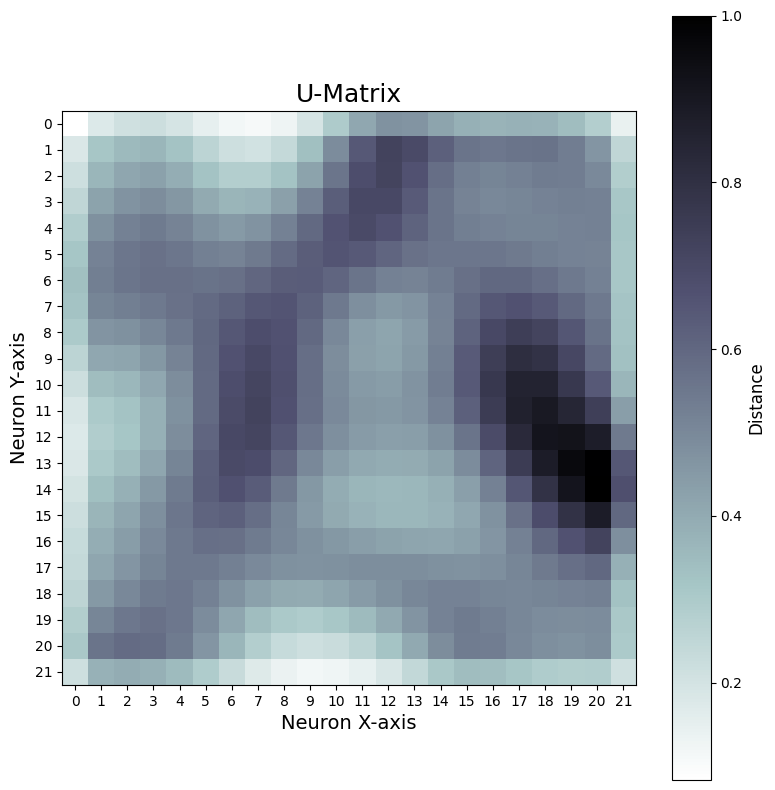

In [ ]:
# Cell 12 
u_matrix = som_clas_200.get_u_matrix()

fig, ax = plt.subplots(figsize=(8,8))

im = ax.imshow(u_matrix, cmap="bone_r")

ax.set_title("U-Matrix", fontsize=18)

ax.set_xlabel("Neuron X-axis", fontsize=14)
ax.set_ylabel("Neuron Y-axis", fontsize=14)

ax.set_xticks(range(som_clas_200.x))
ax.set_yticks(range(som_clas_200.y))

cbar = plt.colorbar(im)
cbar.set_label("Distance", fontsize=12)

plt.tight_layout()
plt.show()

### 13. HITMAP Detalied 

Different colours depending on hits. 

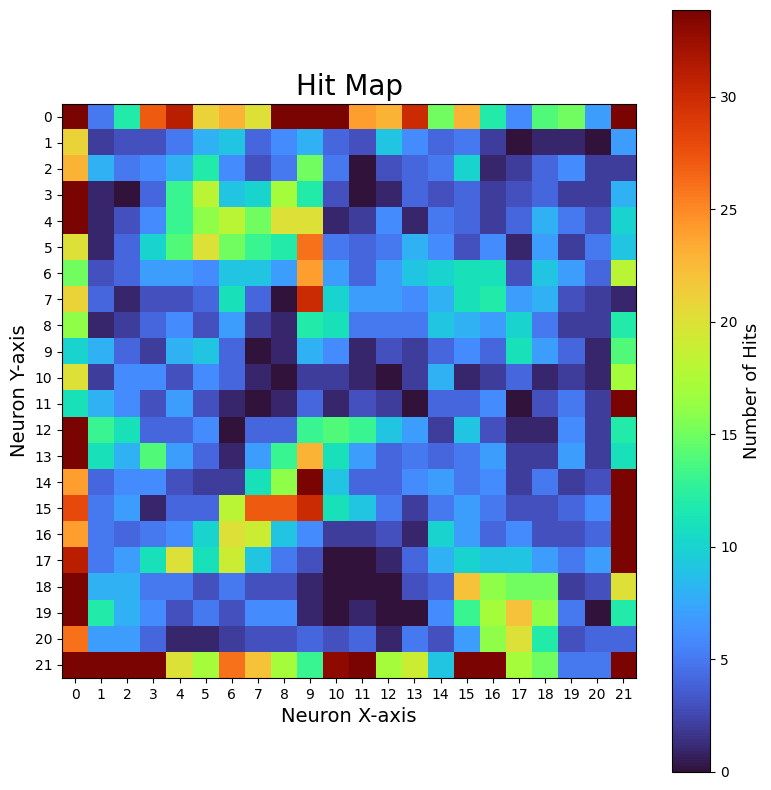

In [15]:
# cell 13

scaled_data = som_clas_200.scaler.transform(df_som)

hits = som_clas_200.som.activation_response(scaled_data)

fig, ax = plt.subplots(figsize=(8,8))

im = ax.imshow(
    hits,
    cmap="turbo",
    vmin=0,
    vmax=np.percentile(hits, 95)
)

ax.set_title("Hit Map", fontsize=20)

ax.set_xlabel("Neuron X-axis", fontsize=14)
ax.set_ylabel("Neuron Y-axis", fontsize=14)

ax.set_xticks(np.arange(som_clas_200.x))
ax.set_yticks(np.arange(som_clas_200.y))


cbar = plt.colorbar(im)

cbar.set_label("Number of Hits", fontsize=13)
plt.tight_layout()
plt.show()

### 14. Cluster map 

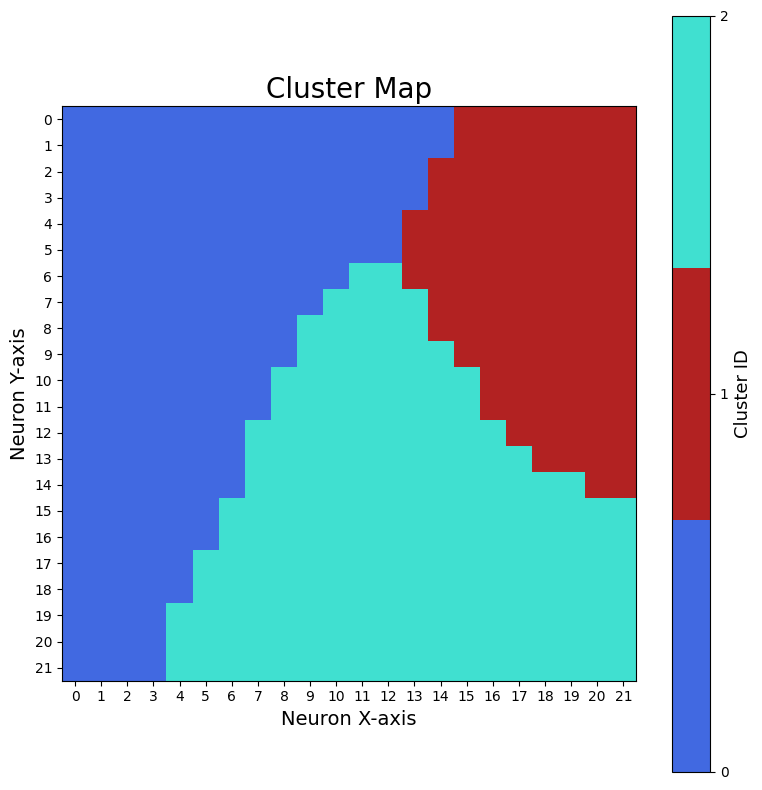

In [ ]:
# Cell 14

cluster_map = som_clas_200.kmeans.labels_.reshape(
    som_clas_200.x,
    som_clas_200.y
)
# Custom colors for clusters

custom_cmap = ListedColormap([
    "royalblue",   # Cluster 0
    "firebrick",   # Cluster 1
    "turquoise"    # Cluster 2
])

fig, ax = plt.subplots(figsize=(8,8))

im = ax.imshow(
    cluster_map,
    cmap=custom_cmap,
    vmin=0,
    vmax=2
)

ax.set_title("Cluster Map", fontsize=20)

ax.set_xlabel("Neuron X-axis", fontsize=14)
ax.set_ylabel("Neuron Y-axis", fontsize=14)

ax.set_xticks(np.arange(som_clas_200.x))
ax.set_yticks(np.arange(som_clas_200.y))


cbar = plt.colorbar(
    im,
    ticks=[0,1,2]
)

cbar.set_label("Cluster ID", fontsize=13)


plt.tight_layout()
plt.show()

### 15. U-matrix with cluster boundaries 

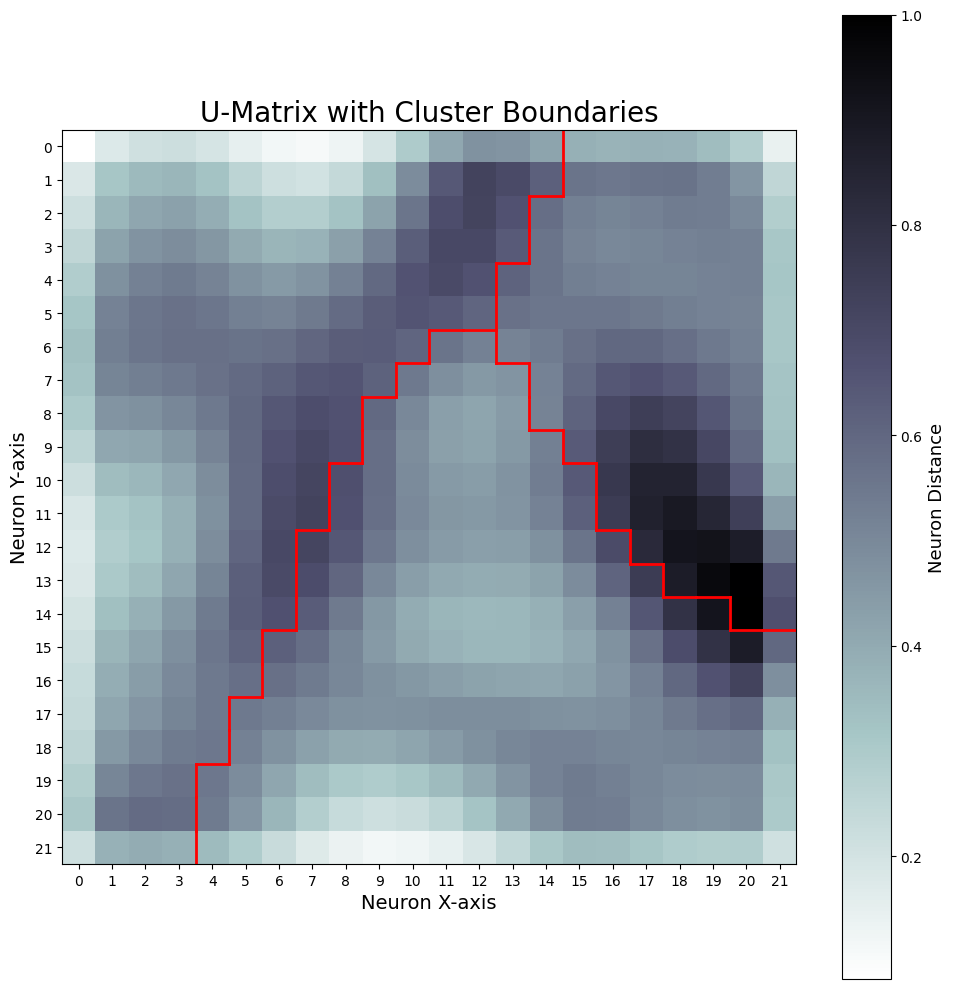

In [ ]:
# Cell 15

u_matrix = som_clas_200.get_u_matrix()

cluster_map = som_clas_200.kmeans.labels_.reshape(
    som_clas_200.x,
    som_clas_200.y
)


fig, ax = plt.subplots(figsize=(10,10))

im = ax.imshow(
    u_matrix,
    cmap="bone_r"
)

# Draw cluster boundaries
for i in range(cluster_map.shape[0]):

    for j in range(cluster_map.shape[1]):

        current = cluster_map[i, j]

        # ---- Compare right neighbor ----
        if j < cluster_map.shape[1] - 1:

            right = cluster_map[i, j+1]

            if current != right:

                ax.plot(
                    [j+0.5, j+0.5],
                    [i-0.5, i+0.5],
                    color="red",
                    linewidth=2
                )

        # ---- Compare bottom neighbor ----
        if i < cluster_map.shape[0] - 1:

            bottom = cluster_map[i+1, j]

            if current != bottom:

                ax.plot(
                    [j-0.5, j+0.5],
                    [i+0.5, i+0.5],
                    color="red",
                    linewidth=2
                )
ax.set_title(
    "U-Matrix with Cluster Boundaries",
    fontsize=20
)

ax.set_xlabel("Neuron X-axis", fontsize=14)
ax.set_ylabel("Neuron Y-axis", fontsize=14)

ax.set_xticks(np.arange(som_clas_200.x))
ax.set_yticks(np.arange(som_clas_200.y))


# Colorbar
cbar = plt.colorbar(im)

cbar.set_label(
    "Neuron Distance",
    fontsize=13
)

plt.tight_layout()
plt.show()

## 16. Cluster analysis

Prediction - Each BMU is then assigned a cluster label from the trained KMeans model.

Basic Stats - Mean and standard deviation for each physiological feature within each cluster

Cluster size - Cluster size and percentage distribution

Feature Importance - F-score to identify which physiological features contribute most to cluster separation

Top features - Ranking of dominant features per cluster

Boxplot - visual comparison of feature distributions between clusters

Cohens effect - analysis to measure the magnitude of physiological differences between clusters

PCA - visualization to project the clustered physiological data into a two-dimensional space for visual inspection of cluster separation



=== MEAN PER CLUSTER ===


,HR,HRV_RMSSD,SC_PH,SC_RR
cluster,,,,
0,75.013860,55.587527,0.691223,0.063544
1,74.446526,46.306015,3.316771,0.073333
2,88.800866,34.648319,1.386802,0.134661



=== STD PER CLUSTER ===


,HR,HRV_RMSSD,SC_PH,SC_RR
cluster,,,,
0,7.550309,12.904128,0.627661,0.051792
1,9.706933,12.772889,0.938085,0.040091
2,10.335198,12.127881,0.703704,0.054867



=== Total Clusters ===


,Count,Percent
cluster,,
0,2637,50.78
1,710,13.67
2,1846,35.55



=== FEATURE IMPORTANCE (ANOVA F-score) ===


SC_PH        3907.549514
HRV_RMSSD    1496.592850
HR           1443.029522
SC_RR        1079.243554
dtype: float64


=== TOP FEATURES PER CLUSTER ===

Cluster 0
HR           75.013860
HRV_RMSSD    55.587527
SC_PH         0.691223
SC_RR         0.063544
Name: 0, dtype: float64

Cluster 1
HR           74.446526
HRV_RMSSD    46.306015
SC_PH         3.316771
SC_RR         0.073333
Name: 1, dtype: float64

Cluster 2
HR           88.800866
HRV_RMSSD    34.648319
SC_PH         1.386802
SC_RR         0.134661
Name: 2, dtype: float64


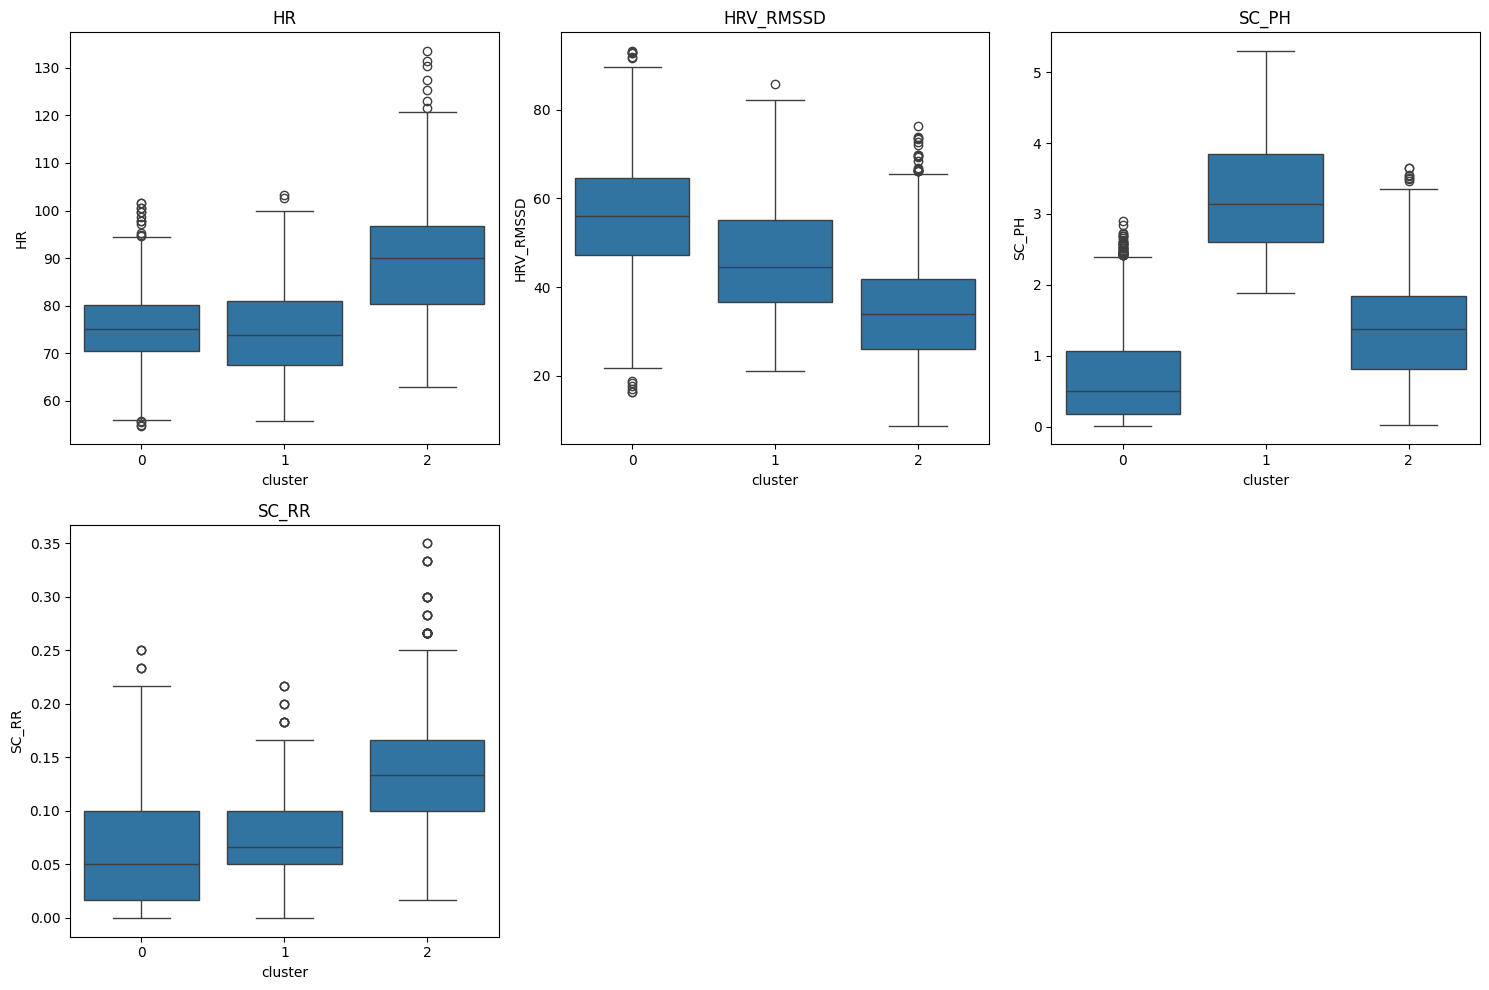


=== COHEN'S D BETWEEN CLUSTERS ===

Cluster 0 vs 1
HR: 0.07
HRV_RMSSD: 0.72
SC_PH: -3.29
SC_RR: -0.21

Cluster 0 vs 2
HR: -1.52
HRV_RMSSD: 1.67
SC_PH: -1.04
SC_RR: -1.33

Cluster 1 vs 2
HR: -1.43
HRV_RMSSD: 0.94
SC_PH: 2.33
SC_RR: -1.28


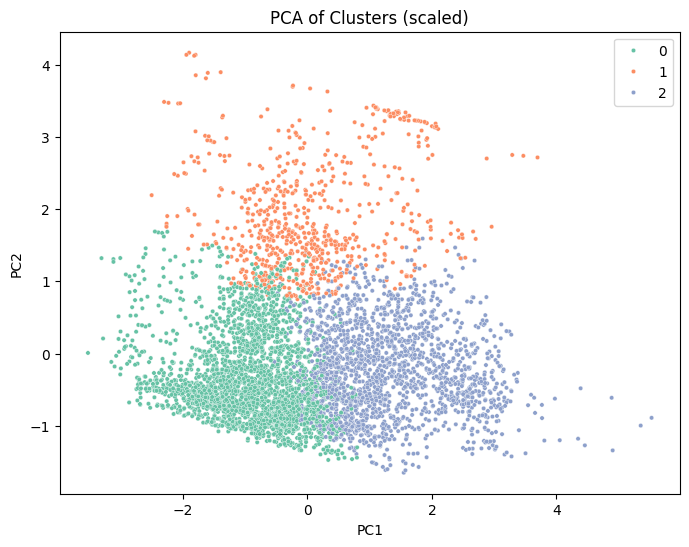

In [ ]:
# Cell 16 

# Using correct DF and features 
feature_names = ["HR", "HRV_RMSSD", "SC_PH", "SC_RR"]

df = pd.DataFrame(df_som, columns=feature_names)

# scale the data using the same scaler as the SOM
scaled_data = som_clas_200.scaler.transform(df_som)

# predict cluster for each sample
winners = np.array([som_clas_200.som.winner(x) for x in scaled_data])

width = som_clas_200.y
flat_idx = winners[:, 0] * width + winners[:, 1]

df["cluster"] = som_clas_200.kmeans.labels_[flat_idx]

#  BASIC STATS
print("\n=== MEAN PER CLUSTER ===")
display(df.groupby("cluster").mean())

print("\n=== STD PER CLUSTER ===")
display(df.groupby("cluster").std())


# CLUSTER SIZE
print("\n=== Total Clusters ===")

cluster_counts = df["cluster"].value_counts().sort_index()

cluster_percent = (
    df["cluster"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

cluster_summary = pd.DataFrame({
    "Count": cluster_counts,
    "Percent": cluster_percent.round(2)
})

display(cluster_summary)


# FEATURE IMPORTANCE - Anova F-score
print("\n=== FEATURE IMPORTANCE (ANOVA F-score) ===")

F, p = f_classif(df[feature_names], df["cluster"])
importance = pd.Series(F, index=feature_names).sort_values(ascending=False)

display(importance)

# TOP FEATURES PER CLUSTER
print("\n=== TOP FEATURES PER CLUSTER ===")

cluster_means = df.groupby("cluster").mean()

for c in cluster_means.index:
    print(f"\nCluster {c}")
    sorted_features = cluster_means.loc[c].sort_values(ascending=False)
    print(sorted_features)

# BOXPLOTS

plt.figure(figsize=(15, 10))

for i, col in enumerate(feature_names):
    plt.subplot(2, 3, i+1)
    sns.boxplot(x="cluster", y=col, data=df)
    plt.title(col)

plt.tight_layout()
plt.show()

# COHEN'S D (EFFECT SIZE)
def cohens_d(x, y):
    return (np.mean(x) - np.mean(y)) / np.sqrt((np.std(x)**2 + np.std(y)**2) / 2)

print("\n=== COHEN'S D BETWEEN CLUSTERS ===")

for (c1, c2) in combinations(sorted(df.cluster.unique()), 2):
    print(f"\nCluster {c1} vs {c2}")
    for col in feature_names:
        d = cohens_d(df[df.cluster==c1][col], df[df.cluster==c2][col])
        print(f"{col}: {d:.2f}")


# PCA (SCALED)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["cluster"],
    palette="Set2",
    s=10
)

plt.title("PCA of Clusters (scaled)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

### 17. Put labels to each cluster

In [ ]:
# cell 17

som_clas_200.set_cluster_labels({
    0: "Rest",
    1: "Neutral/active",
    2: "Stress"
})


### 18. Save h-file for ESP

In [ ]:
# Cell 18

MODEL_DIR = Path("../models")

MODEL_DIR.mkdir(exist_ok=True)

som_clas_200.export_to_c(filepath=MODEL_DIR / "som_model_4_features_check.h")



### 19. Save PKL-file

In [ ]:
# cell 19

MODEL_DIR.mkdir(exist_ok=True)

model_path = MODEL_DIR / "som_model_4_features.pkl"

som_clas_200.save_model(model_path)

print("Model saved to:", model_path)